In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score

## 1 Chargement et Préparation des Données

In [7]:
# Charger les données
df_train = pd.read_csv('Data/train.csv')
df_test = pd.read_csv('Data/test.csv')

# Appliquer log transformation au target AVANT d'identifier les colonnes
Y = np.log1p(df_train['SalePrice'].values)
X_train_raw = df_train.drop(columns=['SalePrice'])
X_test_raw = df_test.copy()

# MAINTENANT identifier les colonnes (après avoir supprimé SalePrice)
numeric_cols = X_train_raw.select_dtypes(include=[np.number]).columns
categorical_cols = X_train_raw.select_dtypes(include=['object']).columns

# Imputer les valeurs manquantes (median pour numériques, mode pour catégoriques)
for col in numeric_cols:
    if X_train_raw[col].isnull().sum() > 0:
        median_val = X_train_raw[col].median()
        X_train_raw[col].fillna(median_val, inplace=True)
        X_test_raw[col].fillna(median_val, inplace=True)

for col in categorical_cols:
    if X_train_raw[col].isnull().sum() > 0:
        mode_val = X_train_raw[col].mode()[0]
        X_train_raw[col].fillna(mode_val, inplace=True)
        X_test_raw[col].fillna(mode_val, inplace=True)

print(f"✅ Données préparées: train {X_train_raw.shape} | test {X_test_raw.shape}")
print(f"   Target log - Moyenne: {Y.mean():.2f}")

✅ Données préparées: train (1460, 80) | test (1459, 80)
   Target log - Moyenne: 12.02


C:\Users\Digi\AppData\Local\Temp\ipykernel_15940\1604912532.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train_raw.select_dtypes(include=['object']).columns
C:\Users\Digi\AppData\Local\Temp\ipykernel_15940\1604912532.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For e

## 2 Prétraitement (Scaling + Encoding)

In [8]:
# Créer un préprocesseur avec ColumnTransformer
numeric_transformer = Pipeline([('scaler', StandardScaler())])
categorical_transformer = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols.tolist()),
    ('cat', categorical_transformer, categorical_cols.tolist())
])

# Appliquer le préprocesseur
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)
X_train_processed = np.nan_to_num(X_train_processed, nan=0.0)
X_test_processed = np.nan_to_num(X_test_processed, nan=0.0)

# Split train/validation (2/3 train, 1/3 validation)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_train_processed, Y, test_size=1/3, random_state=42)

print(f"Données transformées:")
print(f"   Features: {X_train_processed.shape[1]}")
print(f"   Train: {X_train.shape[0]} | Validation: {X_val.shape[0]} | Test: {X_test_processed.shape[0]}")

Données transformées:
   Features: 304
   Train: 973 | Validation: 487 | Test: 1459


## 3 Entraînement du Modèle Lasso

In [9]:
# Entraîner avec LassoCV pour trouver le meilleur alpha
lasso_cv = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, random_state=42, max_iter=10000, n_jobs=-1)
lasso_cv.fit(X_train, Y_train)

# Réentraîner le modèle final
lasso_final = LassoCV(alphas=[lasso_cv.alpha_], cv=5, random_state=42, max_iter=10000)
lasso_final.fit(X_train, Y_train)

# Évaluation
def rmsle(y_true, y_pred):
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

Y_train_pred = lasso_final.predict(X_train)
Y_val_pred = lasso_final.predict(X_val)

train_r2 = r2_score(Y_train, Y_train_pred)
val_r2 = r2_score(Y_val, Y_val_pred)
val_rmsle = rmsle(Y_val, Y_val_pred)

print(f"Modèle entraîné:")
print(f"   Alpha optimal: {lasso_cv.alpha_:.6f}")
print(f"   Train R²: {train_r2:.4f} | Validation R²: {val_r2:.4f} | RMSLE: {val_rmsle:.4f}")
print(f"   Features utilisées: {np.sum(lasso_final.coef_ != 0)} / {len(lasso_final.coef_)} ({100*np.sum(lasso_final.coef_ != 0)/len(lasso_final.coef_):.1f}%)")

Modèle entraîné:
   Alpha optimal: 0.001000
   Train R²: 0.9107 | Validation R²: 0.8932 | RMSLE: 0.0105
   Features utilisées: 100 / 304 (32.9%)


## 4 Visualisations

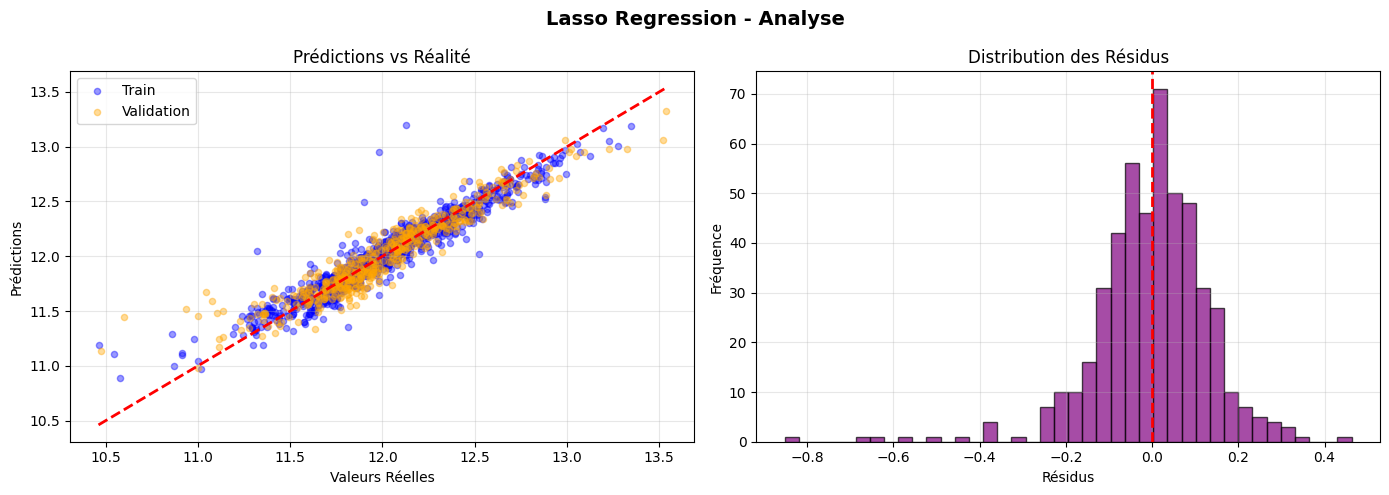

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Lasso Regression - Analyse', fontsize=14, fontweight='bold')

# Prédictions vs Réalité
ax1 = axes[0]
ax1.scatter(Y_train, Y_train_pred, alpha=0.4, s=20, color='blue', label='Train')
ax1.scatter(Y_val, Y_val_pred, alpha=0.4, s=20, color='orange', label='Validation')
min_v, max_v = min(Y_train.min(), Y_val.min()), max(Y_train.max(), Y_val.max())
ax1.plot([min_v, max_v], [min_v, max_v], 'r--', lw=2)
ax1.set_xlabel('Valeurs Réelles')
ax1.set_ylabel('Prédictions')
ax1.set_title('Prédictions vs Réalité')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Résidus
ax2 = axes[1]
residuals = Y_val - Y_val_pred
ax2.hist(residuals, bins=40, edgecolor='black', alpha=0.7, color='purple')
ax2.axvline(x=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Résidus')
ax2.set_ylabel('Fréquence')
ax2.set_title('Distribution des Résidus')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5 Top Features


+ : Top 10 Features (Positif - augmente le prix):
  Neighborhood_Crawfor             0.1030
  Neighborhood_StoneBr             0.0947
  OverallQual                      0.0910
  GrLivArea                        0.0896
  Exterior1st_BrkFace              0.0849
  Neighborhood_NridgHt             0.0573
  BsmtQual_Ex                      0.0565
  BsmtExposure_Gd                  0.0547
  Condition1_Norm                  0.0514
  GarageCars                       0.0475

- : Top 10 Features (Négatif - diminue le prix):
  RoofMatl_ClyTile                -0.4047
  LandContour_Bnk                 -0.0595
  Condition2_PosN                 -0.0578
  MSZoning_RM                     -0.0573
  SaleCondition_Abnorml           -0.0454
  CentralAir_N                    -0.0450
  Neighborhood_Edwards            -0.0309
  BsmtFinType1_Unf                -0.0304
  BldgType_Twnhs                  -0.0299
  MSSubClass                      -0.0284


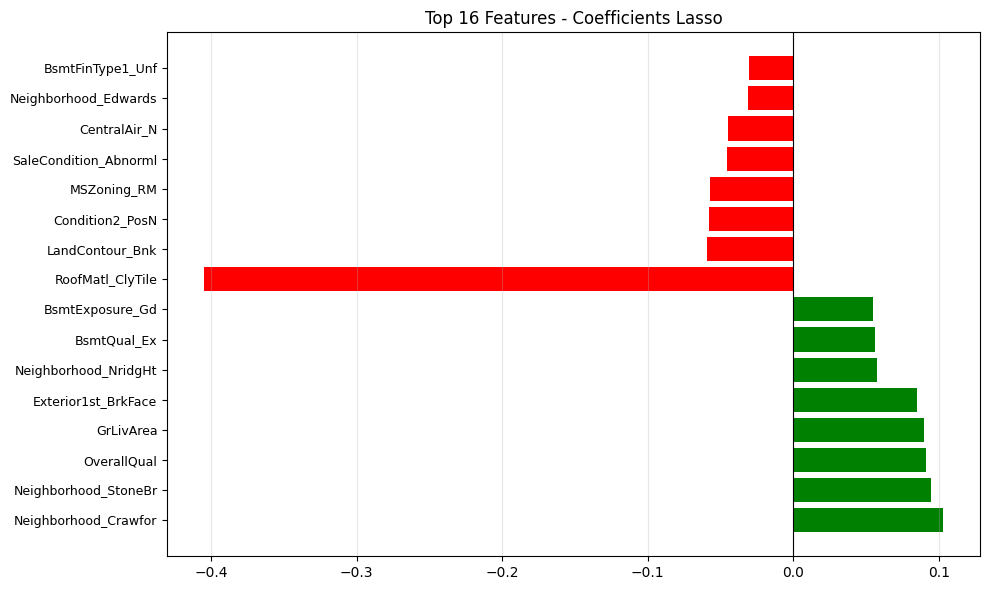

In [11]:
# Récupérer les noms des features
feature_names = []
for name in numeric_cols:
    feature_names.append(name)
for idx, cat in enumerate(categorical_cols):
    onehot = preprocessor.named_transformers_['cat'].named_steps['onehot']
    for cat_val in onehot.categories_[idx]:
        feature_names.append(f"{cat}_{cat_val}")

# Top features positifs et négatifs
coef_df = pd.DataFrame({'Feature': feature_names, 'Coef': lasso_final.coef_})

print("\n+ : Top 10 Features (Positif - augmente le prix):")
for idx, row in coef_df.nlargest(10, 'Coef').iterrows():
    print(f"  {row['Feature']:30s} {row['Coef']:8.4f}")

print("\n- : Top 10 Features (Négatif - diminue le prix):")
for idx, row in coef_df.nsmallest(10, 'Coef').iterrows():
    print(f"  {row['Feature']:30s} {row['Coef']:8.4f}")

# Visualisation
coef_top = pd.concat([coef_df.nlargest(8, 'Coef'), coef_df.nsmallest(8, 'Coef')])
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in coef_top['Coef']]
ax.barh(range(len(coef_top)), coef_top['Coef'], color=colors)
ax.set_yticks(range(len(coef_top)))
ax.set_yticklabels(coef_top['Feature'], fontsize=9)
ax.axvline(x=0, color='black', linestyle='-', lw=0.8)
ax.set_title('Top 16 Features - Coefficients Lasso')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 6 Prédictions Kaggle

In [12]:
# Générer les prédictions finales
Y_test_pred_log = lasso_final.predict(X_test_processed)
Y_test_pred = np.expm1(Y_test_pred_log)  # Convertir de log scale à original scale

# Créer la soumission Kaggle
submission_df = pd.DataFrame({
    'Id': df_test['Id'].values,
    'SalePrice': Y_test_pred
})

submission_df.to_csv('submission_lasso_simplified.csv', index=False)

print("\nPrédictions finales:")
print(f"   Min: ${Y_test_pred.min():,.0f}")
print(f"   Max: ${Y_test_pred.max():,.0f}")
print(f"   Moyenne: ${Y_test_pred.mean():,.0f}")
print(f"\nFichier soumission créé: submission_lasso_simplified.csv")
print(f"\nRésumé Final:")
print(f"   Validation R²: {val_r2:.4f}")
print(f"   Validation RMSLE: {val_rmsle:.4f}")
print(f"   Alpha: {lasso_cv.alpha_:.6f}")
print(f"   Prédictions: {len(Y_test_pred)}")


Prédictions finales:
   Min: $58,280
   Max: $685,826
   Moyenne: $175,614

Fichier soumission créé: submission_lasso_simplified.csv

Résumé Final:
   Validation R²: 0.8932
   Validation RMSLE: 0.0105
   Alpha: 0.001000
   Prédictions: 1459
